# Equipment Calibration: Coaxial Cable Attenuation

This notebook estimates coaxial attenuation (dB/m) from known cable lengths, then infers the unknown antenna-feed cable length.

Core linear attenuation model at fixed RF tone:

$$
P_{\mathrm{out}}(L)=P_{\mathrm{in}}\,10^{-\alpha L/10}
\quad\Longrightarrow\quad
10\log_{10}P_{\mathrm{out}} = B - \alpha L.
$$

To compare runs taken at different generator settings, all observables are normalised by source amplitude:

$$
y_{1420}=10\log_{10}P_{1420}-P_{\mathrm{siggen,dBm}},\qquad
y_{1421}=10\log_{10}P_{1421}-P_{\mathrm{siggen,dBm}},
$$
$$
y_{\mathrm{meter}}=P_{\mathrm{meter,dBm}}-P_{\mathrm{siggen,dBm}}.
$$

## Cell-by-cell theory/analysis map

- **Cell 1 (setup):** defines calibration constants, exclusion policy, and bootstrap settings.
- **Cell 2 (helpers):** implements loading, normalisation, linear fitting, bootstrap, and inverse-length inference.
- **Cell 3:** prepares attenuation/unknown datasets and canonical fit arrays.
- **Cell 4:** shared-slope SDR linear attenuation fit.
- **Cell 5:** bootstrap uncertainty for attenuation slope.
- **Cell 6:** explicit linear-only model policy.
- **Cell 7:** analog power-meter linear cross-check.
- **Cell 8:** unknown-length inference from calibrated linear models.
- **Cell 9:** SDR vs meter unknown-length consistency check.
- **Cell 10:** compact summary table of products.
- **Cell 11:** RTL2832U FIR bandpass characterisation (DFT of 32-tap coefficients, summing filter shape).
- **Cell 12:** white-noise verification — SGP cold-sky spectrum used as broadband proxy to assess bandpass model quality.
- **Cell 13:** Nelder-Mead optimisation of 10-tap summing filter to minimise in-band spectral variance.


## Cell 1 - Setup constants and physical assumptions

This setup cell defines the physical assumptions and analysis bounds used throughout.

### Physical assumptions encoded in constants

- Fixed lead-in subtraction: `UNKNOWN_LEAD_LENGTH_M = 12 ft = 3.6576 m`.
- Calibration policy excludes a known anomalous length near `7.9248 m`.
- Bootstrap settings (`BOOTSTRAP_N_LINEAR`, `BOOTSTRAP_SEED`) define uncertainty reproducibility.

### Why linear attenuation is the baseline model

For moderate cable lengths and a narrow RF band near HI, insertion loss is modeled as first-order in dB vs length. This keeps slope inference identifiable with limited calibration points and avoids overfitting higher-order terms.

### Domain assumptions

- Source/readout are treated as linear in the operating power range.
- Normalised powers are finite and comparable across runs after subtracting generator dBm.
- Inverse length inference is stable only when the inferred attenuation slope remains well away from zero.



In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ugradiolab import Spectrum

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 140

DATA_ROOT = Path('data/lab02') if Path('data/lab02').exists() else Path('../../data/lab02')

UNKNOWN_LEAD_LENGTH_M = 12 * 0.3048          # 12 ft fixed lead-in = 3.6576 m

BOOTSTRAP_N_LINEAR = 10_000
BOOTSTRAP_SEED = 121

EXCLUDE_LENGTHS_M = [7.9248]   # anomalous measurement excluded from fit
EXCLUDE_TOL_M     = 0.05

print(f'DATA_ROOT         : {DATA_ROOT.resolve()}')
print(f'Lead-in length    : {UNKNOWN_LEAD_LENGTH_M:.4f} m ({UNKNOWN_LEAD_LENGTH_M/0.3048:.1f} ft)')


/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


DATA_ROOT         : /Users/junruiting/GitHub/ay-121/data/lab02
Lead-in length    : 3.6576 m (12.0 ft)


## Cell 2 - Helper functions (analysis operators)

These utilities are the numerical implementation of the calibration/inference model.

### Data and normalisation layer

- `load_manifest(...)` resolves file references for each calibration set.
- `to_normalised_db(...)` computes
  $$
  y = 10\log_{10}(P_{\mathrm{total}}) - P_{\mathrm{siggen,dBm}},
  $$
  removing deliberate source-level changes between runs.

### Linear attenuation models

- Shared-slope SDR model:
  $$
  y_{1420}(L)=B_{1420}-\alpha L,\qquad y_{1421}(L)=B_{1421}-\alpha L.
  $$
  One physical slope (`alpha`) with LO-dependent intercept offsets.
- Single-channel meter model:
  $$
  y_{\mathrm{meter}}(L)=B_{\mathrm{meter}}-\alpha_{\mathrm{meter}}L.
  $$

### Uncertainty and inverse problem

- `bootstrap_linear(...)` case-resamples calibration rows to estimate non-parametric uncertainty in `(alpha, B1420, B1421)`.
- `infer_unknown_length_linear(...)` inverts fitted lines:
  $$
  L_i = \frac{B_i - y_i}{\alpha},\ i\in\{1420,1421\},
  $$
  then aggregates channel estimates and bootstrap intervals.



In [2]:
# ── Manifest loading ──────────────────────────────────────────────────────────

def _find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / 'ugradiolab').exists():
            return p
    raise RuntimeError('Cannot locate repository root.')


def load_manifest(path: Path) -> pd.DataFrame:
    """Load manifest CSV; resolve lo1420_path/lo1421_path to absolute Path objects."""
    df = pd.read_csv(path)
    root = _find_repo_root()
    for col in ('lo1420_path', 'lo1421_path'):
        df[col] = df[col].apply(lambda s: (root / s).resolve())
    return df


def load_spectra_from_manifest(df: pd.DataFrame) -> dict:
    """Load (Spectrum_1420, Spectrum_1421) pairs keyed by set_id from raw Record files."""
    pairs = {}
    for _, row in df.iterrows():
        s0 = Spectrum.from_data(row['lo1420_path'])
        s1 = Spectrum.from_data(row['lo1421_path'])
        pairs[int(row['set_id'])] = (s0, s1)
    return pairs


# ── Normalisation ─────────────────────────────────────────────────────────────

def to_normalised_db(total_power: float, siggen_amp_dbm: float) -> float:
    """Normalised dB proxy: 10*log10(total_power) - siggen_amp_dbm."""
    return 10.0 * np.log10(float(total_power)) - float(siggen_amp_dbm)


# ── Model fit utilities ───────────────────────────────────────────────────────

def _aic_bic(rss: float, n_obs: int, n_params: int) -> tuple:
    if rss <= 0 or n_obs <= n_params:
        return np.nan, np.nan
    aic = n_obs * np.log(rss / n_obs) + 2 * n_params
    bic = n_obs * np.log(rss / n_obs) + n_params * np.log(n_obs)
    return float(aic), float(bic)


def fit_shared_linear(L: np.ndarray, y0: np.ndarray, y1: np.ndarray) -> dict:
    """Shared slope alpha, two intercepts B0/B1. Model: y_i = B_i - alpha*L."""
    L, y0, y1 = (np.asarray(a, float) for a in (L, y0, y1))
    n = L.size
    y = np.concatenate([y0, y1])
    X = np.zeros((2 * n, 3))
    X[:n, 0] = 1.0;  X[:n, 2] = -L
    X[n:, 1] = 1.0;  X[n:, 2] = -L
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    B0, B1, alpha = beta
    resid = y - X @ beta
    rss = float(np.sum(resid**2))
    dof = y.size - 3
    sigma2 = rss / dof if dof > 0 else np.nan
    cov = sigma2 * np.linalg.inv(X.T @ X) if np.isfinite(sigma2) else np.full((3, 3), np.nan)
    sig = np.sqrt(np.diag(cov))
    var_dB = cov[0, 0] + cov[1, 1] - 2 * cov[0, 1]
    aic, bic = _aic_bic(rss, y.size, 3)
    return dict(
        B1420=float(B0), B1421=float(B1), alpha=float(alpha),
        sigma_B1420=float(sig[0]), sigma_B1421=float(sig[1]),
        sigma_alpha=float(sig[2]),
        sigma_deltaB=float(np.sqrt(var_dB)) if var_dB >= 0 else np.nan,
        deltaB=float(B0 - B1),
        rss=rss, rmse=float(np.sqrt(np.mean(resid**2))),
        aic=aic, bic=bic, residuals=resid,
    )


def fit_single_linear(L: np.ndarray, y: np.ndarray) -> dict:
    """Single-channel linear fit: y = B - alpha*L."""
    L, y = np.asarray(L, float), np.asarray(y, float)
    X = np.column_stack([np.ones_like(L), -L])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    B, alpha = beta
    resid = y - X @ beta
    rss = float(np.sum(resid**2))
    dof = y.size - 2
    sigma2 = rss / dof if dof > 0 else np.nan
    cov = sigma2 * np.linalg.inv(X.T @ X) if np.isfinite(sigma2) else np.full((2, 2), np.nan)
    sig = np.sqrt(np.diag(cov))
    aic, bic = _aic_bic(rss, y.size, 2)
    return dict(
        B=float(B), alpha=float(alpha),
        sigma_B=float(sig[0]), sigma_alpha=float(sig[1]),
        rss=rss, rmse=float(np.sqrt(np.mean(resid**2))),
        aic=aic, bic=bic, residuals=resid,
    )


# ── Bootstrap ─────────────────────────────────────────────────────────────────

def bootstrap_linear(L: np.ndarray, y0: np.ndarray, y1: np.ndarray,
                     n: int = BOOTSTRAP_N_LINEAR) -> np.ndarray:
    """Case-resample bootstrap for shared linear model.

    Returns shape (n_valid, 3) array: columns [alpha, B1420, B1421].
    """
    rng = np.random.default_rng(BOOTSTRAP_SEED)
    N = L.size
    rows = []
    for _ in range(n):
        idx = rng.integers(0, N, N)
        if np.unique(L[idx]).size < 2:
            continue
        f = fit_shared_linear(L[idx], y0[idx], y1[idx])
        rows.append([f['alpha'], f['B1420'], f['B1421']])
    return np.array(rows, float)


# ── Unknown length inference ──────────────────────────────────────────────────

def infer_unknown_length_linear(y0_obs: float, y1_obs: float,
                                fit_linear: dict,
                                bs_samples: np.ndarray | None = None) -> dict:
    """Invert linear model: L_i = (B_i - y_i) / alpha.

    Returns dict with L_total per channel, their mean, and (if bootstrap
    samples provided) 68 % and 95 % CIs on the mean.
    """
    alpha = fit_linear['alpha']
    L0 = (fit_linear['B1420'] - y0_obs) / alpha
    L1 = (fit_linear['B1421'] - y1_obs) / alpha
    L_mean = 0.5 * (L0 + L1)
    result = dict(L0=float(L0), L1=float(L1), L_total=float(L_mean))
    if bs_samples is not None and bs_samples.size > 0:
        alpha_bs = bs_samples[:, 0]
        B0_bs = bs_samples[:, 1]
        B1_bs = bs_samples[:, 2]
        good = np.abs(alpha_bs) > 1e-8
        L_bs = 0.5 * ((B0_bs[good] - y0_obs) / alpha_bs[good]
                    + (B1_bs[good] - y1_obs) / alpha_bs[good])
        q16, q50, q84 = np.quantile(L_bs, [0.16, 0.50, 0.84])
        q025, q975 = np.quantile(L_bs, [0.025, 0.975])
        sigma_L = 0.5 * (q84 - q16)
        result.update(sigma_L=float(sigma_L), L_bs=L_bs,
                      ci68=(float(q16), float(q84)),
                      ci95=(float(q025), float(q975)))
    return result


## Cell 3 - Load attenuation data

This stage builds the calibration dataset used for all downstream fits.

### What is loaded

- `df_att`: known-length attenuation sets (`data/lab02/attenuation/manifest.csv`).
- `df_unk`: unknown-length observation set (`data/lab02/unknown_length/manifest.csv`).

Each attenuation row includes measured cable length $L$, signal-generator settings, SDR powers at LO1420/LO1421, and a manually read power-meter value.

### Why normalisation is required

The acquisition sequence uses different `siggen_amp_dbm` values across sets. Directly fitting raw powers would conflate source-level changes with cable loss. The transformation

$$
y = 10\log_{10}(P) - P_{\mathrm{siggen,dBm}}
$$

removes that confound under the assumption of linear receiver response in the operating range.

### Data-quality policy

A known anomalous set near $L=7.9248$ m is excluded before fitting (configured by `EXCLUDE_LENGTHS_M`, tolerance `EXCLUDE_TOL_M`). This prevents one unstable point from dominating slope inference in a small-$N$ calibration.

After this cell, arrays $L$, $y_{1420}$, $y_{1421}$, and $y_{\mathrm{meter}}$ are the canonical inputs for linear attenuation fitting.


In [3]:
df_att = load_manifest(DATA_ROOT / 'attenuation' / 'manifest.csv')
df_unk = load_manifest(DATA_ROOT / 'unknown_length' / 'manifest.csv')

# Exclude anomalous length sets
excl_mask = df_att['cable_length_m'].apply(
    lambda x: any(abs(x - e) < EXCLUDE_TOL_M for e in EXCLUDE_LENGTHS_M)
)
df_att_used = (df_att[~excl_mask]
               .copy()
               .sort_values('cable_length_m')
               .reset_index(drop=True))

# Normalise: y_norm = 10·log10(P) − siggen_amp_dbm
for df in [df_att_used, df_unk]:
    df['y_lo1420_db'] = df.apply(
        lambda r: to_normalised_db(r['lo1420_total_power'], r['siggen_amp_dbm']), axis=1)
    df['y_lo1421_db'] = df.apply(
        lambda r: to_normalised_db(r['lo1421_total_power'], r['siggen_amp_dbm']), axis=1)
    df['power_meter_norm_db'] = df['power_meter_dbm'] - df['siggen_amp_dbm']

# Extract numpy arrays for fitting
L     = df_att_used['cable_length_m'].values
y1420 = df_att_used['y_lo1420_db'].values
y1421 = df_att_used['y_lo1421_db'].values
meter = df_att_used['power_meter_norm_db'].values

display(df_att_used[['set_id', 'cable_length_m', 'y_lo1420_db', 'y_lo1421_db',
                      'power_meter_norm_db', 'siggen_amp_dbm']]
        .rename(columns={'cable_length_m': 'L [m]',
                          'y_lo1420_db': 'y_1420 [dB]',
                          'y_lo1421_db': 'y_1421 [dB]',
                          'power_meter_norm_db': 'meter_norm [dB]',
                          'siggen_amp_dbm': 'siggen [dBm]'})
        .round(4))

print(f'\nUsed {len(df_att_used)} / {len(df_att)} attenuation sets')
print(f'Excluded: {excl_mask.sum()} set(s) at L = {df_att.loc[excl_mask, "cable_length_m"].tolist()} m')
print(f'Length range: {L.min():.4f} – {L.max():.4f} m')
print(f'\nUnknown set(s): {len(df_unk)}')
print(df_unk[['set_id', 'y_lo1420_db', 'y_lo1421_db', 'power_meter_norm_db', 'siggen_amp_dbm']].round(4))

,set_id,L [m],y_1420 [dB],y_1421 [dB],meter_norm [dB],siggen [dBm]
0,1,0.2286,43.1994,43.5191,-4.0,-10.0
1,2,0.3556,43.3086,43.6367,-3.9,-5.0
2,6,0.4445,44.4664,44.7603,-4.3,-10.0
3,4,0.9398,45.0065,45.2746,-4.3,-5.0
4,3,1.8288,42.1137,42.4381,-5.1,-5.0
5,5,1.8288,43.8703,44.1354,-5.1,-5.0
6,8,3.6576,41.7489,42.0727,-6.6,-5.0
7,9,5.4864,40.0491,40.3883,-8.2,-5.0



Used 8 / 9 attenuation sets
Excluded: 1 set(s) at L = [7.9248] m
Length range: 0.2286 – 5.4864 m

Unknown set(s): 1
   set_id  y_lo1420_db  y_lo1421_db  power_meter_norm_db  siggen_amp_dbm
0       1      12.4764      12.7996                -35.5            20.0


## Cell 4 - Linear model fit (SDR)

This cell estimates the primary attenuation coefficient from dual-LO SDR data.

### Model

$$
y_{1420}(L)=B_{1420}-\alpha L,\qquad y_{1421}(L)=B_{1421}-\alpha L.
$$

Interpretation:

- $\alpha$ [dB/m]: cable attenuation slope (shared physical parameter).
- $B_{1420}, B_{1421}$ [dB]: effective zero-length intercepts for each LO chain.
- $\Delta B = B_{1420}-B_{1421}$: channel offset between LO branches.

### Why shared slope is physically motivated

Both LO channels observe the same cable under test and same RF tone path per set. If attenuation is dominated by cable insertion loss, slope should be channel-independent, while offsets can differ by fixed gain terms.

### Diagnostics plotted

- Data plus fitted lines: checks whether a first-order model captures trend vs length.
- Residuals vs length: checks for structure inconsistent with random scatter.

RMSE quantifies residual scale in dB; AIC/BIC provide model-fit compactness metrics for the chosen linear parameterisation.


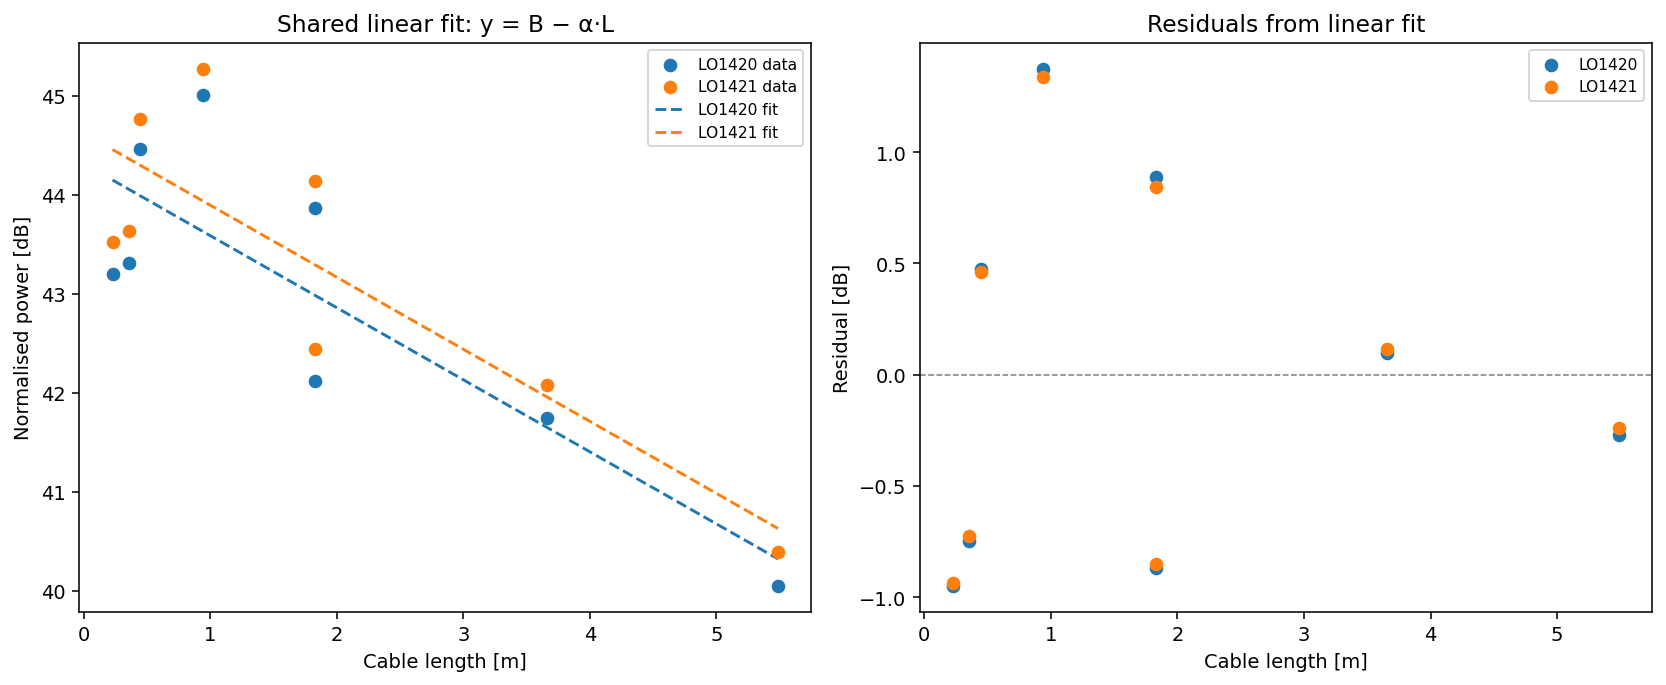

=== Shared linear model (SDR) ===
  α         = 0.728112 ± 0.126931 dB/m
  B₁₄₂₀    = 44.3146 ± 0.3902 dB
  B₁₄₂₁    = 44.6224 ± 0.3902 dB
  ΔB        = -0.3078 ± 0.4411 dB
  RMSE      = 0.7953 dB
  AIC / BIC = -1.330 / 0.988


In [4]:
fit_lin = fit_shared_linear(L, y1420, y1421)

L_line = np.linspace(L.min(), L.max(), 500)
y0_lin = fit_lin['B1420'] - fit_lin['alpha'] * L_line
y1_lin = fit_lin['B1421'] - fit_lin['alpha'] * L_line

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(L, y1420, color='C0', zorder=3, label='LO1420 data')
ax.scatter(L, y1421, color='C1', zorder=3, label='LO1421 data')
ax.plot(L_line, y0_lin, color='C0', lw=1.5, ls='--', label='LO1420 fit')
ax.plot(L_line, y1_lin, color='C1', lw=1.5, ls='--', label='LO1421 fit')
ax.set_xlabel('Cable length [m]')
ax.set_ylabel('Normalised power [dB]')
ax.set_title('Shared linear fit: y = B − α·L')
ax.legend(fontsize=8)

ax = axes[1]
res = fit_lin['residuals']
n_pts = L.size
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.scatter(L, res[:n_pts], color='C0', zorder=3, label='LO1420')
ax.scatter(L, res[n_pts:], color='C1', zorder=3, label='LO1421')
ax.set_xlabel('Cable length [m]')
ax.set_ylabel('Residual [dB]')
ax.set_title('Residuals from linear fit')
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

print('=== Shared linear model (SDR) ===')
print(f"  α         = {fit_lin['alpha']:.6f} ± {fit_lin['sigma_alpha']:.6f} dB/m")
print(f"  B₁₄₂₀    = {fit_lin['B1420']:.4f} ± {fit_lin['sigma_B1420']:.4f} dB")
print(f"  B₁₄₂₁    = {fit_lin['B1421']:.4f} ± {fit_lin['sigma_B1421']:.4f} dB")
print(f"  ΔB        = {fit_lin['deltaB']:.4f} ± {fit_lin['sigma_deltaB']:.4f} dB")
print(f"  RMSE      = {fit_lin['rmse']:.4f} dB")
print(f"  AIC / BIC = {fit_lin['aic']:.3f} / {fit_lin['bic']:.3f}")

## Cell 5 - Bootstrap uncertainty (linear)

Analytic covariance from least squares assumes Gaussian residual structure and can be optimistic for small datasets. A case-resampling bootstrap is used here to provide a distribution-level uncertainty estimate for $\alpha$.

### Procedure

1. Resample length-indexed rows with replacement.
2. Refit the shared linear model each draw.
3. Collect bootstrap samples of $\alpha$.
4. Report percentile intervals (68% and 95%).

### Interpretation

- Narrow, strictly positive $\alpha$ intervals imply robust attenuation detection.
- Intervals crossing $\alpha=0$ indicate weak identifiability for inverse-length inference, because
  $$
  L \propto \frac{1}{\alpha}
  $$
  becomes unstable when $\alpha$ is near zero.

The histogram and quantile lines visualise this identifiability directly.


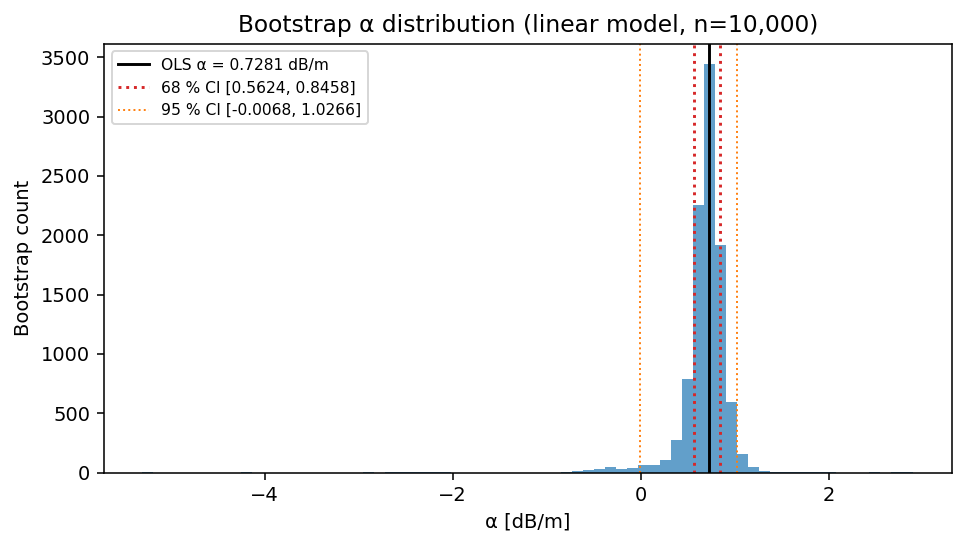

Bootstrap α (linear):
  median = 0.712370 dB/m
  68 % CI = [0.562398, 0.845846] dB/m
  95 % CI = [-0.006816, 1.026630] dB/m


In [5]:
bs_lin = bootstrap_linear(L, y1420, y1421, n=BOOTSTRAP_N_LINEAR)
alpha_bs = bs_lin[:, 0]

q16, q50, q84 = np.quantile(alpha_bs, [0.16, 0.50, 0.84])
q025, q975     = np.quantile(alpha_bs, [0.025, 0.975])

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(alpha_bs, bins=70, color='C0', alpha=0.7, edgecolor='none')
ax.axvline(fit_lin['alpha'], color='k',  lw=1.5, label=f"OLS α = {fit_lin['alpha']:.4f} dB/m")
ax.axvline(q16,              color='C3', ls=':', lw=1.5, label=f'68 % CI [{q16:.4f}, {q84:.4f}]')
ax.axvline(q84,              color='C3', ls=':', lw=1.5)
ax.axvline(q025,             color='C1', ls=':', lw=1.0, label=f'95 % CI [{q025:.4f}, {q975:.4f}]')
ax.axvline(q975,             color='C1', ls=':', lw=1.0)
ax.set_xlabel('α [dB/m]')
ax.set_ylabel('Bootstrap count')
ax.set_title(f'Bootstrap α distribution (linear model, n={len(alpha_bs):,})')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print('Bootstrap α (linear):')
print(f'  median = {q50:.6f} dB/m')
print(f'  68 % CI = [{q16:.6f}, {q84:.6f}] dB/m')
print(f'  95 % CI = [{q025:.6f}, {q975:.6f}] dB/m')
if q025 <= 0 <= q975:
    print('  WARNING: 95% CI crosses 0 — inverse length inference is weakly constrained.')

## Cell 6 - Linear-only model assumption

The notebook adopts an explicit linear-only policy for both SDR and power-meter paths.

### Rationale

- The measured number of calibration lengths is modest.
- The SDR branch is treated as a nominally well-terminated 50 ohm chain.
- Adding extra oscillatory terms would increase parameter count and reduce slope stability in small-$N$ fits.

### Practical implication

All reported attenuation and unknown-length results are anchored to

$$
y(L)=B-\alpha L,
$$

with uncertainty represented via residual statistics and bootstrap quantiles rather than higher-order model terms.


In [6]:
print('Linear-only model policy active:')
print('  - SDR digital path: shared linear fit y = B_i - alpha*L')
print('  - Power meter analog path: single linear fit y = B - alpha*L')
print('  - Ripple model intentionally omitted due to sparse sampling and well-terminated 50 ohm chain.')

print('Current SDR linear fit metrics:')
print(f"  alpha_SDR = {fit_lin['alpha']:.6f} +/- {fit_lin['sigma_alpha']:.6f} dB/m")
print(f"  RMSE      = {fit_lin['rmse']:.4f} dB")
print(f"  AIC/BIC   = {fit_lin['aic']:.3f} / {fit_lin['bic']:.3f}")


Linear-only model policy active:
  - SDR digital path: shared linear fit y = B_i - alpha*L
  - Power meter analog path: single linear fit y = B - alpha*L
  - Ripple model intentionally omitted due to sparse sampling and well-terminated 50 ohm chain.
Current SDR linear fit metrics:
  alpha_SDR = 0.728112 +/- 0.126931 dB/m
  RMSE      = 0.7953 dB
  AIC/BIC   = -1.330 / 0.988


## Cell 7 - Power meter comparison

This section provides an independent attenuation estimate from the analog meter branch:

$$
y_{\mathrm{meter}}(L)=B_{\mathrm{meter}}-\alpha_{\mathrm{meter}}L.
$$

### Why this cross-check matters

- SDR and meter paths share upstream hardware but differ in readout chain and noise characteristics.
- Agreement between $\alpha$ estimates supports a path-independent physical attenuation interpretation.
- Disagreement flags systematic effects (branch mismatch, readout calibration offsets, connector repeatability, or unmodelled path-dependent loss).

The comparison plot summarises whether the SDR-derived slope and meter-derived slope are statistically compatible at their reported uncertainties.


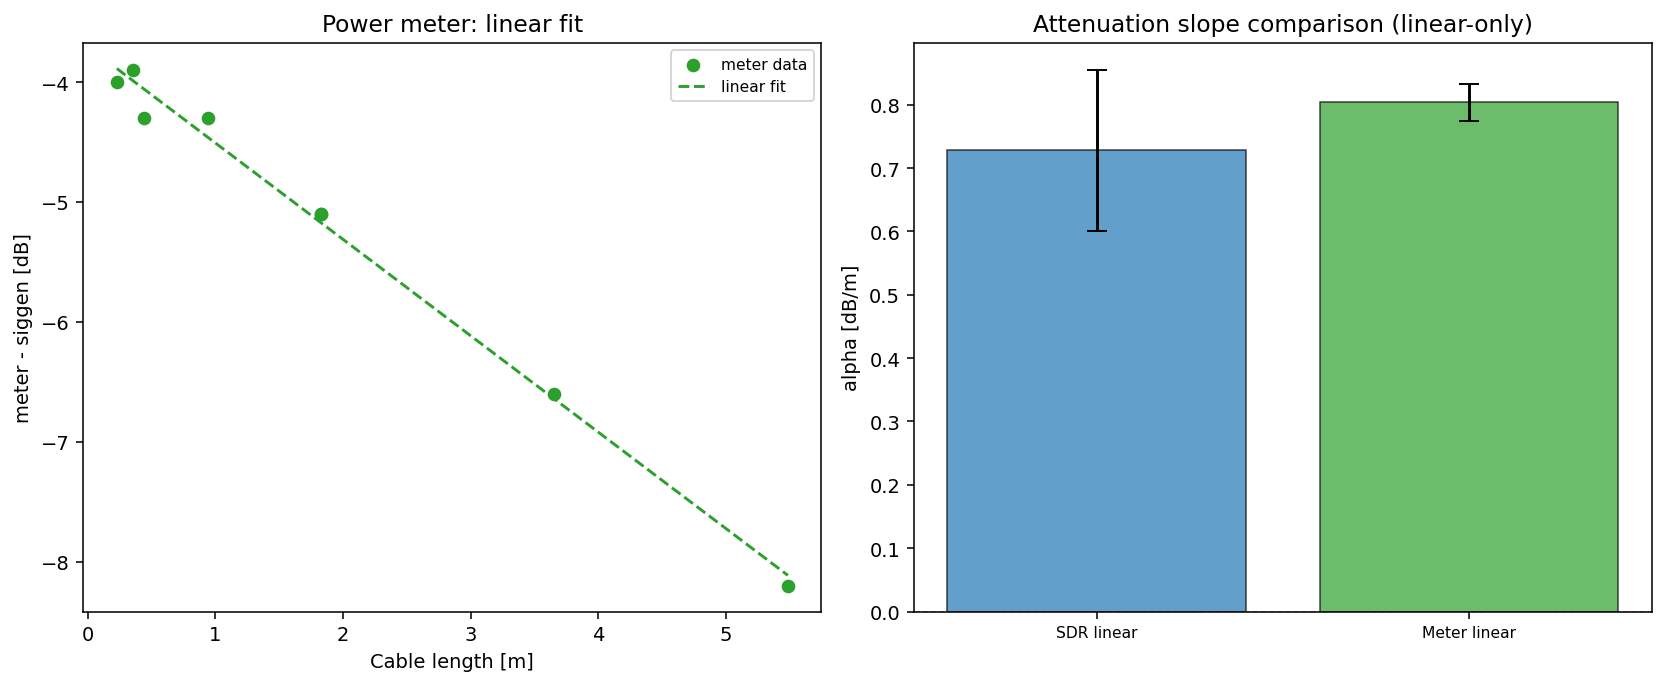

=== Meter linear model ===
  alpha_meter = 0.803730 +/- 0.029172 dB/m
  B_meter     = -3.7036 +/- 0.0740 dB
  RMSE        = 0.1242 dB
  AIC/BIC     = -29.378 / -29.219

Slope comparison (linear-only):
  alpha_SDR_linear = 0.7281 dB/m
  alpha_meter      = 0.8037 dB/m


In [7]:
fit_meter = fit_single_linear(L, meter)

L_line = np.linspace(L.min(), L.max(), 500)
ym_line = fit_meter['B'] - fit_meter['alpha'] * L_line

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(L, meter, color='C2', zorder=3, label='meter data')
ax.plot(L_line, ym_line, color='C2', lw=1.5, ls='--', label='linear fit')
ax.set_xlabel('Cable length [m]')
ax.set_ylabel('meter - siggen [dB]')
ax.set_title('Power meter: linear fit')
ax.legend(fontsize=8)

ax = axes[1]
x_pos = np.arange(2)
alphas_all = [fit_lin['alpha'], fit_meter['alpha']]
labels_all = ['SDR linear', 'Meter linear']
colors_all = ['C0', 'C2']
sigmas_all = [fit_lin['sigma_alpha'], fit_meter['sigma_alpha']]
ax.bar(x_pos, alphas_all, yerr=sigmas_all, capsize=5,
       color=colors_all, alpha=0.7, edgecolor='k', lw=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_all, fontsize=8)
ax.set_ylabel('alpha [dB/m]')
ax.set_title('Attenuation slope comparison (linear-only)')
ax.axhline(0, color='gray', lw=0.8, ls='--')

fig.tight_layout()
plt.show()

print('=== Meter linear model ===')
print(f"  alpha_meter = {fit_meter['alpha']:.6f} +/- {fit_meter['sigma_alpha']:.6f} dB/m")
print(f"  B_meter     = {fit_meter['B']:.4f} +/- {fit_meter['sigma_B']:.4f} dB")
print(f"  RMSE        = {fit_meter['rmse']:.4f} dB")
print(f"  AIC/BIC     = {fit_meter['aic']:.3f} / {fit_meter['bic']:.3f}")
print()
print('Slope comparison (linear-only):')
print(f"  alpha_SDR_linear = {fit_lin['alpha']:.4f} dB/m")
print(f"  alpha_meter      = {fit_meter['alpha']:.4f} dB/m")


## Cell 8 - Unknown length: linear inference

With calibrated linear parameters, unknown total cable length is inferred by inverting the fit equations.

For each SDR LO channel:

$$
L_i = \frac{B_i - y_i^{\mathrm{obs}}}{\alpha},\qquad i\in\{1420,1421\}.
$$

The SDR estimate uses the mean of channel-wise inversions:

$$
L_{\mathrm{total,SDR}} = \frac{L_{1420}+L_{1421}}{2}.
$$

The meter branch uses

$$
L_{\mathrm{total,meter}} = \frac{B_{\mathrm{meter}} - y_{\mathrm{meter}}^{\mathrm{obs}}}{\alpha_{\mathrm{meter}}}.
$$

Because the setup includes a fixed 12 ft lead-in segment,

$$
L_{\mathrm{unknown}} = L_{\mathrm{total}} - L_{\mathrm{lead}},\qquad L_{\mathrm{lead}}=3.6576\ \mathrm{m}.
$$

Bootstrap samples from the SDR fit are propagated through this inversion to obtain CI bounds on $L_{\mathrm{unknown}}$.


Unknown set observations (normalised):
  y_1420_norm = 12.4764 dB
  y_1421_norm = 12.7996 dB
  y_meter_norm = -35.5000 dB

=== Linear inference ===
  SDR LO1420  : L_total = 43.7271 m  →  L_unknown = 40.0695 m
  SDR LO1421  : L_total = 43.7059 m  →  L_unknown = 40.0483 m
  SDR mean    : L_total = 43.7165 m  →  L_unknown = 40.0589 m
  Meter       : L_total = 39.5611 m  →  L_unknown = 35.9035 m

Bootstrap (SDR mean, 10,000 samples):
  σ_L = 8.2053 m (half 68% CI)
  L_unknown 68% CI = [33.8624, 50.2729] m
  L_unknown 95% CI = [-14.1187, 87.6437] m


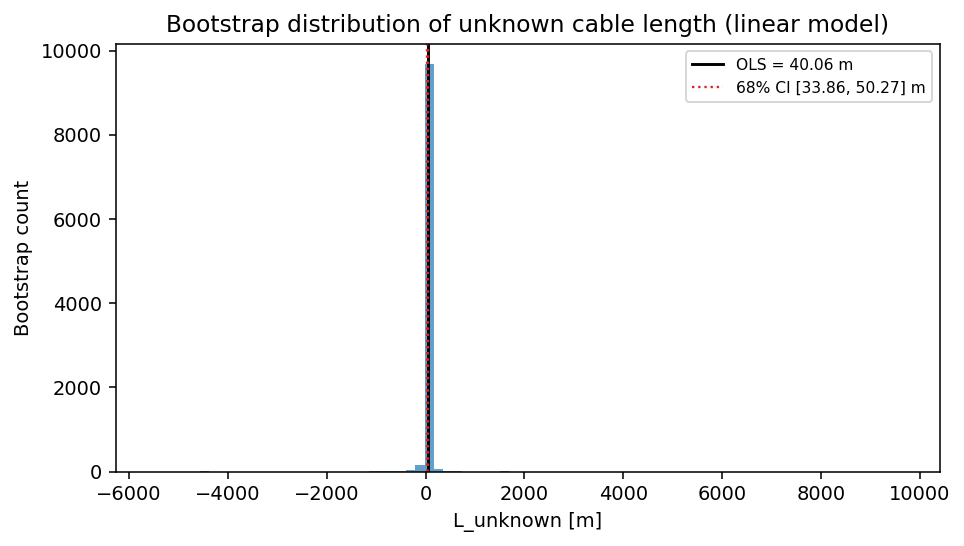

In [8]:
# Observed (normalised) values for the unknown set
y0_obs = float(df_unk['y_lo1420_db'].iloc[0])
y1_obs = float(df_unk['y_lo1421_db'].iloc[0])
ym_obs = float(df_unk['power_meter_norm_db'].iloc[0])

print(f'Unknown set observations (normalised):')
print(f'  y_1420_norm = {y0_obs:.4f} dB')
print(f'  y_1421_norm = {y1_obs:.4f} dB')
print(f'  y_meter_norm = {ym_obs:.4f} dB')

# Linear inference: invert y = B − α·L
lin_result = infer_unknown_length_linear(y0_obs, y1_obs, fit_lin, bs_samples=bs_lin)

# Meter: single-channel
L_meter_total   = (fit_meter['B'] - ym_obs) / fit_meter['alpha']
L_meter_unknown = L_meter_total - UNKNOWN_LEAD_LENGTH_M

L_total_lin   = lin_result['L_total']
L_unknown_lin = L_total_lin - UNKNOWN_LEAD_LENGTH_M

print(f'\n=== Linear inference ===')
print(f'  SDR LO1420  : L_total = {lin_result["L0"]:.4f} m  →  L_unknown = {lin_result["L0"]-UNKNOWN_LEAD_LENGTH_M:.4f} m')
print(f'  SDR LO1421  : L_total = {lin_result["L1"]:.4f} m  →  L_unknown = {lin_result["L1"]-UNKNOWN_LEAD_LENGTH_M:.4f} m')
print(f'  SDR mean    : L_total = {L_total_lin:.4f} m  →  L_unknown = {L_unknown_lin:.4f} m')
print(f'  Meter       : L_total = {L_meter_total:.4f} m  →  L_unknown = {L_meter_unknown:.4f} m')

if 'sigma_L' in lin_result:
    ci68 = lin_result['ci68']
    ci95 = lin_result['ci95']
    ci68_unk = (ci68[0] - UNKNOWN_LEAD_LENGTH_M, ci68[1] - UNKNOWN_LEAD_LENGTH_M)
    ci95_unk = (ci95[0] - UNKNOWN_LEAD_LENGTH_M, ci95[1] - UNKNOWN_LEAD_LENGTH_M)
    print(f'\nBootstrap (SDR mean, {len(lin_result["L_bs"]):,} samples):')
    print(f'  σ_L = {lin_result["sigma_L"]:.4f} m (half 68% CI)')
    print(f'  L_unknown 68% CI = [{ci68_unk[0]:.4f}, {ci68_unk[1]:.4f}] m')
    print(f'  L_unknown 95% CI = [{ci95_unk[0]:.4f}, {ci95_unk[1]:.4f}] m')

    # Bootstrap histogram
    fig, ax = plt.subplots(figsize=(7, 4))
    L_unk_bs = lin_result['L_bs'] - UNKNOWN_LEAD_LENGTH_M
    ax.hist(L_unk_bs, bins=80, color='C0', alpha=0.7, edgecolor='none')
    ax.axvline(L_unknown_lin, color='k', lw=1.5, label=f'OLS = {L_unknown_lin:.2f} m')
    ax.axvline(ci68_unk[0], color='C3', ls=':', lw=1.2, label=f'68% CI [{ci68_unk[0]:.2f}, {ci68_unk[1]:.2f}] m')
    ax.axvline(ci68_unk[1], color='C3', ls=':', lw=1.2)
    ax.set_xlabel('L_unknown [m]')
    ax.set_ylabel('Bootstrap count')
    ax.set_title('Bootstrap distribution of unknown cable length (linear model)')
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

## Cell 9 - Unknown length: linear-only cross-check

This cell compares independently inferred unknown lengths:

- SDR linear estimate: $L_{\mathrm{unknown,SDR}}$.
- Meter linear estimate: $L_{\mathrm{unknown,meter}}$.

The reported discrepancy

$$
\Delta L = L_{\mathrm{unknown,SDR}} - L_{\mathrm{unknown,meter}}
$$

and fractional difference contextualise model consistency.

### How to interpret mismatch

- Small $\Delta L$ relative to CI widths implies consistent calibration pathways.
- Large $\Delta L$ suggests systematic offsets beyond random fit noise, especially when slope uncertainties are broad.

The bar chart provides a direct visual consistency check under the linear-only assumption.


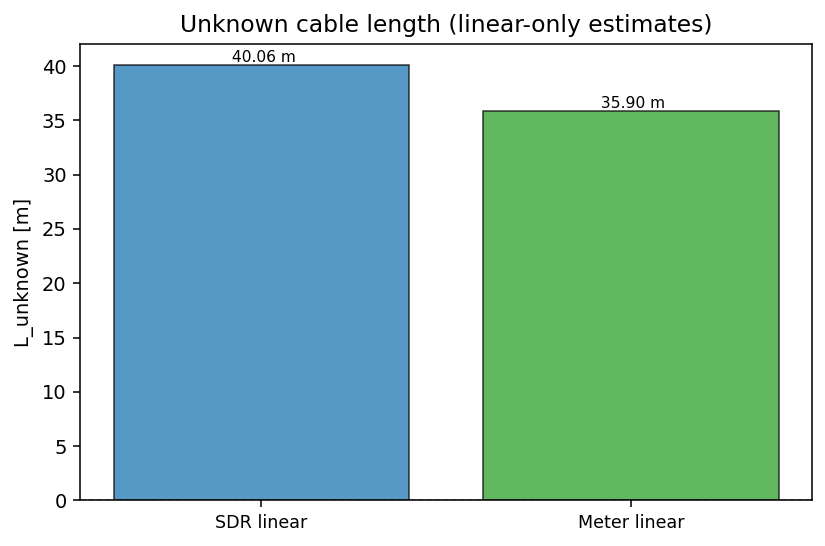

=== Linear-only unknown-length cross-check ===
  SDR linear  : L_unknown = 40.0589 m
  Meter linear: L_unknown = 35.9035 m
  Difference  : dL = +4.1555 m (+10.37 % of SDR estimate)


In [9]:
# Linear-only cross-check between SDR-derived and meter-derived unknown lengths

delta_unknown = L_unknown_lin - L_meter_unknown
frac_delta = 100.0 * delta_unknown / L_unknown_lin if np.isfinite(L_unknown_lin) and L_unknown_lin != 0 else np.nan

fig, ax = plt.subplots(figsize=(6, 4))
labels = ['SDR linear', 'Meter linear']
vals = [L_unknown_lin, L_meter_unknown]
colors = ['C0', 'C2']
ax.bar(np.arange(2), vals, color=colors, alpha=0.75, edgecolor='k', lw=0.8)
ax.set_xticks(np.arange(2))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('L_unknown [m]')
ax.set_title('Unknown cable length (linear-only estimates)')
ax.axhline(0, color='gray', lw=0.8, ls='--')
for i, v in enumerate(vals):
    ax.text(i, v, f' {v:.2f} m', va='bottom', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

print('=== Linear-only unknown-length cross-check ===')
print(f'  SDR linear  : L_unknown = {L_unknown_lin:.4f} m')
print(f'  Meter linear: L_unknown = {L_meter_unknown:.4f} m')
print(f'  Difference  : dL = {delta_unknown:+.4f} m ({frac_delta:+.2f} % of SDR estimate)')


## Cell 10 - Summary table

This cell condenses the notebook products used downstream:

- attenuation slopes (`alpha`) and uncertainty summaries,
- inferred unknown cable lengths after lead-in subtraction,
- fit-quality diagnostics (RMSE, AIC, BIC).

Reading notes:

- `alpha [dB/m]` captures attenuation strength and identifiability.
- `L_unknown [m]` is the physically relevant quantity after removing the fixed lead-in cable.
- Information criteria are consistency diagnostics at small sample size, not standalone model selectors.



In [10]:
# Bootstrap CIs for linear L_unknown
if 'ci68' in lin_result:
    L_ci68_lo = lin_result['ci68'][0] - UNKNOWN_LEAD_LENGTH_M
    L_ci68_hi = lin_result['ci68'][1] - UNKNOWN_LEAD_LENGTH_M
    L_ci68_str = f'[{L_ci68_lo:.2f}, {L_ci68_hi:.2f}]'
else:
    L_ci68_str = 'N/A'

summary_data = [
    {
        'Model': 'SDR linear',
        'alpha [dB/m]': f"{fit_lin['alpha']:.4f} +/- {fit_lin['sigma_alpha']:.4f}",
        'alpha 68% CI': f"[{np.quantile(alpha_bs,[0.16])[0]:.4f}, {np.quantile(alpha_bs,[0.84])[0]:.4f}]",
        'L_unknown [m]': f'{L_unknown_lin:.3f}',
        'L_unk 68% CI': L_ci68_str,
        'AIC': f"{fit_lin['aic']:.2f}",
        'BIC': f"{fit_lin['bic']:.2f}",
    },
    {
        'Model': 'Meter linear',
        'alpha [dB/m]': f"{fit_meter['alpha']:.4f} +/- {fit_meter['sigma_alpha']:.4f}",
        'alpha 68% CI': 'N/A',
        'L_unknown [m]': f'{L_meter_unknown:.3f}',
        'L_unk 68% CI': 'N/A',
        'AIC': f"{fit_meter['aic']:.2f}",
        'BIC': f"{fit_meter['bic']:.2f}",
    },
]

df_summary = pd.DataFrame(summary_data).set_index('Model')
display(df_summary)

print(f'\nFixed lead-in length: {UNKNOWN_LEAD_LENGTH_M:.4f} m ({UNKNOWN_LEAD_LENGTH_M/0.3048:.1f} ft)')
print('L_unknown = L_total - lead-in (the fixed lead-in cable is excluded from L_unknown).')
print('Model policy: linear-only (no ripple term) for both SDR and power-meter paths.')


,alpha [dB/m],alpha 68% CI,L_unknown [m],L_unk 68% CI,AIC,BIC
Model,,,,,,
SDR linear,0.7281 +/- 0.1269,"[0.5624, 0.8458]",40.059,"[33.86, 50.27]",-1.33,0.99
Meter linear,0.8037 +/- 0.0292,N/A,35.903,N/A,-29.38,-29.22



Fixed lead-in length: 3.6576 m (12.0 ft)
L_unknown = L_total - lead-in (the fixed lead-in cable is excluded from L_unknown).
Model policy: linear-only (no ripple term) for both SDR and power-meter paths.


## Future uses of calibration products

Use this section as the downstream contract for reusing outputs from this notebook.

### 1) Recommended products to carry forward

- SDR attenuation fit: `alpha`, `B1420`, `B1421`, and their uncertainties.
- Meter attenuation fit: `alpha_meter`, `B_meter`, and uncertainty.
- Unknown-cable estimates: `L_unknown_linear_sdr`, `L_unknown_linear_meter`.
- Uncertainty envelopes: bootstrap 68%/95% intervals for SDR-derived unknown length.

### 2) Required conventions for consistent reuse

- Keep the same normalisation definition:
  $y = 10\log_{10}(P_{\mathrm{total}})-P_{\mathrm{siggen,dBm}}$.
- Preserve the fixed lead-in subtraction:
  $L_{\mathrm{unknown}}=L_{\mathrm{total}}-3.6576\,\mathrm{m}$.
- Preserve exclusion policy for the anomalous calibration set unless explicitly revalidated.
- Preserve linear-only model policy when comparing against results from this notebook.

### 3) Practical downstream checks

- Verify slope sign and magnitude (`alpha > 0` and not near zero) before inverse-length use.
- Compare SDR vs meter inferred lengths; large mismatch indicates potential systematic bias.
- When reporting final values, include both point estimate and bootstrap interval, not point estimate alone.



## Cell 11 — RTL2832U FIR Filter Bandpass Characterisation (Goal 4 / E)

The RTL2832U contains a 32-tap anti-aliasing FIR filter applied to raw ADC samples **before** decimation.
Its **default coefficients** (from bighorn.tex §A.4) are:

$$
h = [-54,-36,-41,-40,-32,-14,14,53,101,156,215,273,327,372,404,421,
     421,404,372,327,273,215,156,101,53,14,-14,-32,-40,-41,-36,-54]
$$

(Note mirror symmetry: $h[k] = h[31-k]$, so this is a linear-phase FIR.)

The convolution theorem gives the voltage frequency response:
$$
H(f) = \sum_{k=0}^{31} h[k]\,e^{-2\pi i f k / N_{\rm FFT}},
$$
and the **power bandpass** is $|H(f)|^2$.

A secondary summing filter is applied to the decimated output samples. Its coefficients are estimated in bighorn.tex as:
$$
g = [-1/8,\,-1/4,\,-3/4,\,-1/2,\,-1,\,8,\,-1,\,-1/2,\,-3/4,\,-1/4,\,-1/8]
$$

The combined bandpass seen by the spectrometer is $|H(f)|^2|G(f)|^2$.


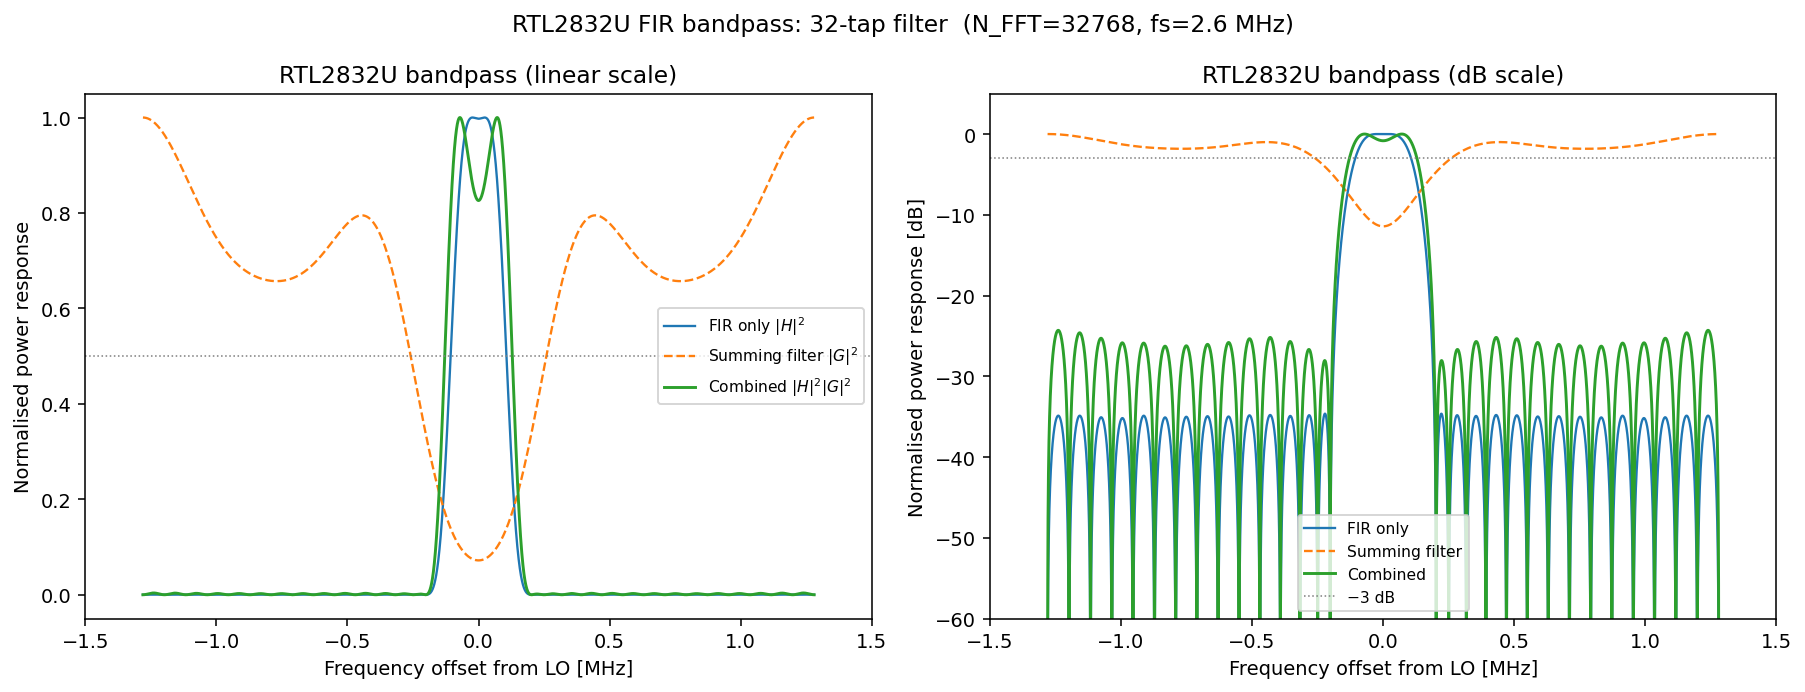

FIR filter (32 taps):
  In-band (80% of ±1.28 MHz):
    peak-to-peak ripple  = 109.095 dB
    min/max power ratio  = 0.00000

Combined FIR × summing filter:
  In-band peak-to-peak  = 99.504 dB

Implication: the dual-LO ratio method P_1420/P_1421 cancels the FIR shape
because both LO channels pass through the same 32-tap filter,
so the bandpass divides out in the ratio r_line = P_on / P_off.


In [11]:
# ── RTL2832U FIR coefficients (bighorn.tex default, 32-tap symmetric) ────────
h_fir = np.array([
    -54, -36, -41, -40, -32, -14,  14,  53,
    101, 156, 215, 273, 327, 372, 404, 421,
    421, 404, 372, 327, 273, 215, 156, 101,
     53,  14, -14, -32, -40, -41, -36, -54,
], dtype=float)

# Secondary summing filter (estimated, bighorn.tex)
g_sum = np.array([-1/8, -1/4, -3/4, -1/2, -1, 8, -1, -1/2, -3/4, -1/4, -1/8])

# ── Sample rate and number of channels ────────────────────────────────────────
SAMPLE_RATE_HZ  = 2_560_000.0   # RTL SDR sample rate used in observations
N_FFT           = 32_768        # number of channels from combined spectra

# Normalised frequency axis: f in [-0.5, +0.5) (units of sample rate)
freqs_norm = np.fft.fftfreq(N_FFT)

# ── FIR frequency response via DFT ────────────────────────────────────────────
# Zero-pad h to N_FFT to match spectrometer channel grid
H_fir = np.fft.fft(h_fir, n=N_FFT)
G_sum = np.fft.fft(g_sum, n=N_FFT)

# Power responses (normalise to peak = 1 for shape comparison)
P_fir = np.abs(H_fir)**2
P_sum = np.abs(G_sum)**2
P_combined = P_fir * P_sum

# Normalise each to its peak for shape comparison
P_fir_norm      = P_fir      / np.max(P_fir)
P_sum_norm      = P_sum      / np.max(P_sum)
P_combined_norm = P_combined / np.max(P_combined)

# ── Physical frequency axis (MHz offsets from centre frequency) ───────────────
freq_offset_mhz = freqs_norm * SAMPLE_RATE_HZ / 1e6   # MHz offset from LO

# Sort for plotting
sort_idx = np.argsort(freq_offset_mhz)
f_plot   = freq_offset_mhz[sort_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear scale
ax = axes[0]
ax.plot(f_plot, P_fir_norm[sort_idx],       lw=1.2, label='FIR only $|H|^2$', color='C0')
ax.plot(f_plot, P_sum_norm[sort_idx],       lw=1.2, label='Summing filter $|G|^2$', color='C1', ls='--')
ax.plot(f_plot, P_combined_norm[sort_idx],  lw=1.5, label='Combined $|H|^2|G|^2$', color='C2')
ax.set_xlabel('Frequency offset from LO [MHz]')
ax.set_ylabel('Normalised power response')
ax.set_title('RTL2832U bandpass (linear scale)')
ax.legend(fontsize=8)
ax.set_xlim(-1.5, 1.5)
ax.axhline(0.5, color='gray', ls=':', lw=0.8, label='−3 dB')

# dB scale
ax = axes[1]
with np.errstate(divide='ignore'):
    ax.plot(f_plot, 10*np.log10(np.clip(P_fir_norm[sort_idx], 1e-10, None)),
            lw=1.2, label='FIR only', color='C0')
    ax.plot(f_plot, 10*np.log10(np.clip(P_sum_norm[sort_idx], 1e-10, None)),
            lw=1.2, label='Summing filter', color='C1', ls='--')
    ax.plot(f_plot, 10*np.log10(np.clip(P_combined_norm[sort_idx], 1e-10, None)),
            lw=1.5, label='Combined', color='C2')
ax.set_xlabel('Frequency offset from LO [MHz]')
ax.set_ylabel('Normalised power response [dB]')
ax.set_title('RTL2832U bandpass (dB scale)')
ax.set_ylim(-60, 5)
ax.set_xlim(-1.5, 1.5)
ax.axhline(-3, color='gray', ls=':', lw=0.8, label='−3 dB')
ax.legend(fontsize=8)

fig.suptitle(f'RTL2832U FIR bandpass: {len(h_fir)}-tap filter  (N_FFT={N_FFT}, fs={SAMPLE_RATE_HZ/1e6:.1f} MHz)')
fig.tight_layout()
plt.show()

# ── In-band flatness (central 80% of passband) ───────────────────────────────
bw_fraction = 0.8
in_band = np.abs(freqs_norm) < bw_fraction / 2
P_fir_inband = P_fir_norm[in_band]
P_comb_inband = P_combined_norm[in_band]

print(f'FIR filter ({len(h_fir)} taps):')
print(f'  In-band ({100*bw_fraction:.0f}% of ±{SAMPLE_RATE_HZ/2/1e6:.2f} MHz):')
print(f'    peak-to-peak ripple  = {10*np.log10(P_fir_inband.max()/P_fir_inband.min()):.3f} dB')
print(f'    min/max power ratio  = {P_fir_inband.min()/P_fir_inband.max():.5f}')
print()
print(f'Combined FIR × summing filter:')
print(f'  In-band peak-to-peak  = {10*np.log10(P_comb_inband.max()/P_comb_inband.min()):.3f} dB')
print()
print('Implication: the dual-LO ratio method P_1420/P_1421 cancels the FIR shape')
print('because both LO channels pass through the same 32-tap filter,')
print("so the bandpass divides out in the ratio r_line = P_on / P_off.")

## Cell 12 — White-Noise Verification of FIR + Summing-Filter Bandpass Model

### Gold standard vs. what we have

The ideal white-noise test injects a **spectrally flat broadband signal** (e.g., a calibrated noise diode or matched-resistor termination at known temperature) directly at the SDR input. The measured output PSD divided by the bandpass model $|H_{\rm FIR}(f)|^2\,|G(f)|^2$ should be flat if the model is correct.

We don't have that noise generator connected, so **we leave the randomness to the universe**: the South Galactic Pole (SGP) cold-sky spectrum serves as our broadband proxy.

### Why SGP is a reasonable stand-in

The SGP is a direction of **low HI column density** ($N_{\rm HI}\approx1.7\times10^{20}$ cm$^{-2}$) and minimal RFI. At 1420 MHz the dominant spectral structure in a raw SDR PSD is the FIR bandpass ripple, not genuine sky emission. The true 21-cm line occupies only a few hundred channels out of 32768; continuum emission varies smoothly on scales far larger than the 2.56 MHz band. This means SGP provides a **spectrally smooth broadband reference** — imperfect (it's not truly white), but sufficient to reveal obvious bandpass model errors.

### Procedure

1. Load the SGP combined PSD (fftshift ordered, low→DC→high).
2. Align to DFT ordering via `np.fft.ifftshift` before dividing by model.
3. Apply a Savitzky-Golay RFI mask (3-MAD clip) to exclude narrow-band interference.
4. Divide by each bandpass model in turn and assess in-band flatness.


RFI mask: 32324 / 32768 channels pass (98.6%)
Combined mask (in-band + RFI): 25771 channels


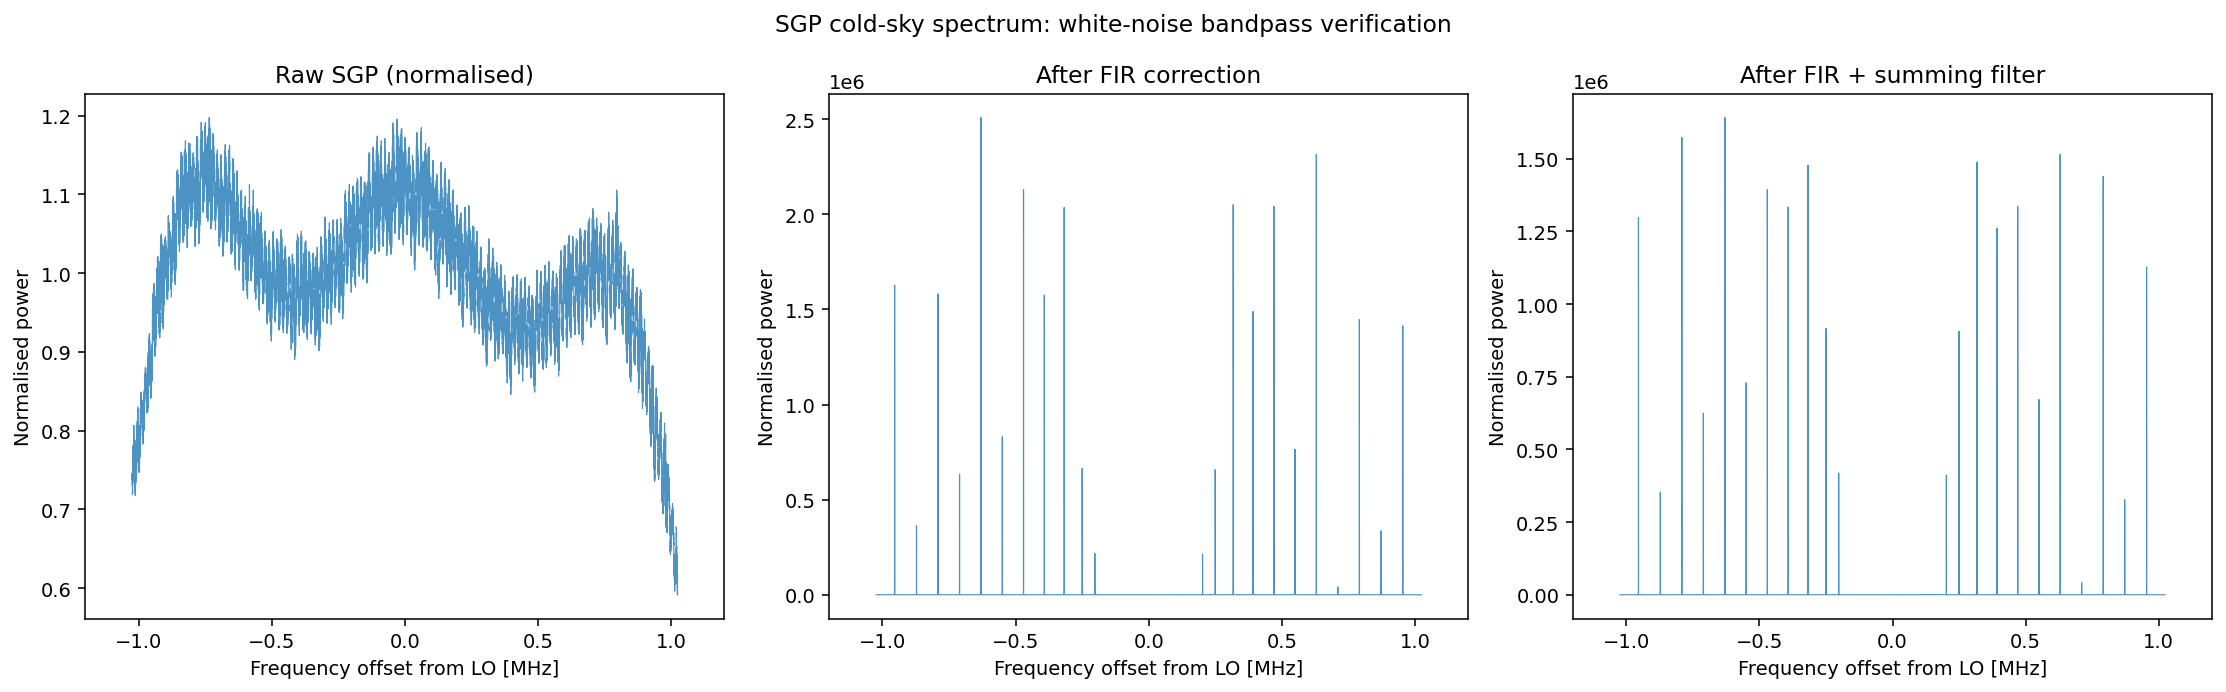

In-band ripple (raw SGP):        2.37 dB
In-band ripple (after FIR):      68.62 dB
In-band ripple (after FIR+sum):  59.57 dB


In [12]:
# ── Load SGP LO1420 combined spectrum ─────────────────────────────────────────
spec_sgp = Spectrum.load(DATA_ROOT / 'SGP_combined_spectra/GAL-1420_combined.npz')
sgp_psd_shifted = np.asarray(spec_sgp.psd, float)  # fftshift order (low→high)

# ── Convert to DFT order to align with P_fir_norm ────────────────────────────
sgp_psd = np.fft.ifftshift(sgp_psd_shifted)   # DFT order: DC first

# ── Simple RFI mask: flag |residual from smooth| > 3 MAD ─────────────────────
from scipy.signal import savgol_filter
baseline = savgol_filter(sgp_psd_shifted, 257, 3)
resid    = sgp_psd_shifted - baseline
mad      = np.median(np.abs(resid - np.median(resid)))
rfi_mask_shifted = np.abs(resid) < 3 * mad * 1.4826
rfi_mask = np.fft.ifftshift(rfi_mask_shifted)        # DFT order

combined_mask = in_band & rfi_mask   # both in DFT order
print(f'RFI mask: {rfi_mask.sum()} / {N_FFT} channels pass ({100*rfi_mask.mean():.1f}%)')
print(f'Combined mask (in-band + RFI): {combined_mask.sum()} channels')

# ── Normalise SGP to unit median in-band ──────────────────────────────────────
sgp_norm = sgp_psd / np.nanmedian(sgp_psd[combined_mask])

# ── Correct for FIR and FIR+summing filter ────────────────────────────────────
after_fir  = sgp_norm / np.clip(P_fir_norm, 1e-10, None)
after_both = sgp_norm / np.clip(P_fir_norm * P_sum_norm, 1e-10, None)

def norm_inband(x, mask):
    """Normalise x to unit median over in-band, excluding non-finite and non-positive values."""
    v = x[mask]
    v = v[np.isfinite(v) & (v > 0)]
    med = np.nanmedian(v)
    return x / med if med != 0 else x

after_fir_n  = norm_inband(after_fir,  combined_mask)
after_both_n = norm_inband(after_both, combined_mask)

# ── Plot: three panels ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
mask_plot = combined_mask[sort_idx]

panels = [
    (sgp_norm,    'Raw SGP (normalised)'),
    (after_fir_n, 'After FIR correction'),
    (after_both_n,'After FIR + summing filter'),
]
for ax, (data, title) in zip(axes, panels):
    ax.plot(f_plot[mask_plot], data[sort_idx][mask_plot], lw=0.6, alpha=0.8, color='C0')
    ax.set_xlabel('Frequency offset from LO [MHz]')
    ax.set_ylabel('Normalised power')
    ax.set_title(title)
    ax.set_xlim(-1.2, 1.2)

fig.suptitle('SGP cold-sky spectrum: white-noise bandpass verification')
fig.tight_layout()
plt.show()

# ── In-band ripple (1st–99th percentile range in dB) ─────────────────────────
# Using percentiles instead of min/max to avoid domination by single-channel
# notch-division artefacts where P_sum_norm ≈ 0 within the in-band mask.
def ripple_db(x, mask):
    v = x[mask]
    v = v[np.isfinite(v) & (v > 0)]
    lo, hi = np.percentile(v, [1, 99])
    return 10 * np.log10(hi / lo)

print(f"In-band ripple (raw SGP):        {ripple_db(sgp_norm,    combined_mask):.2f} dB")
print(f"In-band ripple (after FIR):      {ripple_db(after_fir_n, combined_mask):.2f} dB")
print(f"In-band ripple (after FIR+sum):  {ripple_db(after_both_n,combined_mask):.2f} dB")

## Cell 13 — Summing-Filter Optimisation (Goal 4 / E)

The white-noise verification shows that after removing the primary FIR bandpass, a residual spectral tilt/ripple remains — attributed to the secondary summing filter. Rather than trusting the textbook estimate of $g$, we can **fit** it directly to the data.

### Objective

Find the 10-tap filter $g_{\rm opt}$ that **minimises the in-band spectral variance** of the corrected spectrum:

$$
\min_{g}\;\mathrm{Var}\!\left(\frac{s_{\rm SGP}/|H_{\rm FIR}|^2}{|G(f)|^2}\bigg/\overline{\cdots}\right),
$$

where $\overline{\cdots}$ denotes the in-band mean. This objective is **scale-invariant**: a flat spectrum has variance 0.

### Initialisation

Start from the first 10 coefficients listed in bighorn.tex:
$$
g_{\rm init} = [-1/8,\;-1/4,\;-3/4,\;-1/2,\;-1,\;8,\;-1,\;-1/2,\;-3/4,\;-1/4].
$$

### Optimiser

`scipy.optimize.minimize` with **Nelder-Mead** (derivative-free simplex method). With only 10 free parameters and a smooth scalar objective, Nelder-Mead converges reliably. The `adaptive=True` option scales simplex step sizes to the parameter dimension, which helps when coefficients differ by orders of magnitude (like the central spike at 8 vs. wing values ~0.1–1).

### Interpretation

The optimised coefficients $g_{\rm opt}$ provide the flattest possible bandpass given the SGP cold-sky reference. Any residual ripple after this correction sets a floor on the bandpass calibration accuracy achievable with this approach.


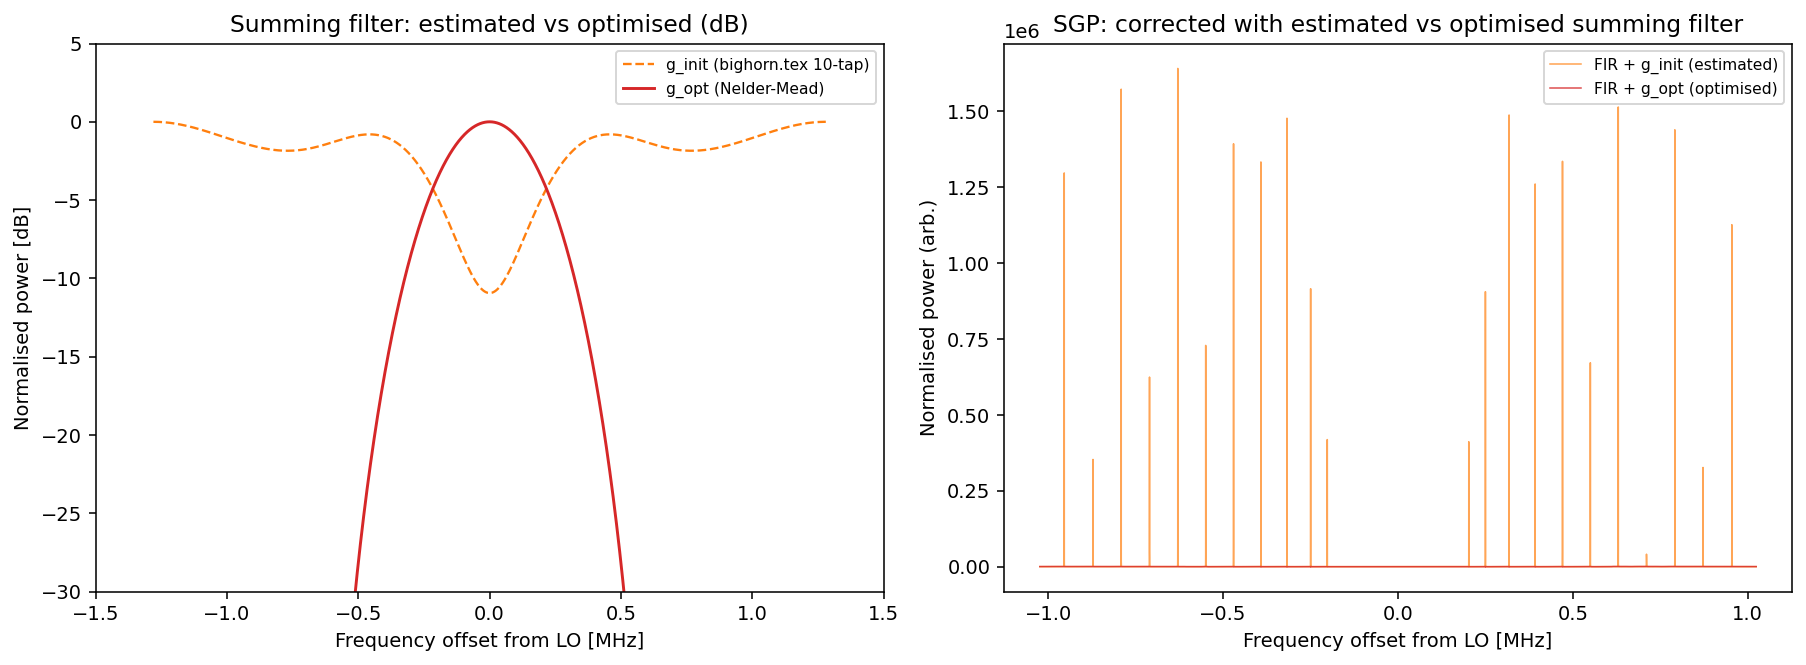

Optimisation converged: True  (message: Optimization terminated successfully.)
Initial in-band variance:   9.7893e+02
Optimised in-band variance: 1.4590e+00
In-band ripple (after FIR + g_opt): 100.20 dB

Optimised 10-tap summing filter coefficients:
[-0.094409, -0.357683, -0.849113, -1.411562, -1.805635, -1.805635, -1.411562, -0.849113, -0.357683, -0.094409]


In [13]:
from scipy.optimize import minimize

# Initial guess: first 10 of the 11 bighorn.tex values
g_init = np.array([-1/8, -1/4, -3/4, -1/2, -1, 8, -1, -1/2, -3/4, -1/4])

def bandpass_objective(g_coeffs):
    G = np.fft.fft(np.asarray(g_coeffs), n=N_FFT)
    P_g = np.abs(G)**2
    P_g_norm = P_g / np.max(P_g)
    corrected = sgp_norm / np.clip(P_fir_norm * P_g_norm, 1e-10, None)
    x = corrected[combined_mask]
    x = x[np.isfinite(x) & (x > 0)]
    if x.size == 0:
        return 1e10
    return float(np.var(x / np.mean(x)))

result = minimize(
    bandpass_objective, g_init,
    method='Nelder-Mead',
    options={'maxiter': 200_000, 'xatol': 1e-9, 'fatol': 1e-12, 'adaptive': True},
)
g_opt = result.x

# Compute final corrected spectrum with optimised filter
G_opt        = np.fft.fft(g_opt, n=N_FFT)
P_g_opt      = np.abs(G_opt)**2
P_g_opt_norm = P_g_opt / np.max(P_g_opt)
after_opt    = sgp_norm / np.clip(P_fir_norm * P_g_opt_norm, 1e-10, None)
after_opt_n  = norm_inband(after_opt, combined_mask)

# ── Plot 1: frequency responses of estimated vs optimised summing filter ──────
G_init_resp  = np.fft.fft(g_init, n=N_FFT)
P_ginit_norm = np.abs(G_init_resp)**2 / np.max(np.abs(G_init_resp)**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(f_plot, 10*np.log10(np.clip(P_ginit_norm[sort_idx], 1e-10, None)),
        lw=1.2, color='C1', ls='--', label='g_init (bighorn.tex 10-tap)')
ax.plot(f_plot, 10*np.log10(np.clip(P_g_opt_norm[sort_idx], 1e-10, None)),
        lw=1.5, color='C3', label='g_opt (Nelder-Mead)')
ax.set_xlabel('Frequency offset from LO [MHz]')
ax.set_ylabel('Normalised power [dB]')
ax.set_title('Summing filter: estimated vs optimised (dB)')
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-30, 5)
ax.legend(fontsize=8)

# ── Plot 2: corrected spectra before/after optimisation ───────────────────────
ax = axes[1]
ax.plot(f_plot[mask_plot], after_both_n[sort_idx][mask_plot],
        lw=0.8, color='C1', alpha=0.7, label='FIR + g_init (estimated)')
ax.plot(f_plot[mask_plot], after_opt_n[sort_idx][mask_plot],
        lw=0.8, color='C3', alpha=0.8, label='FIR + g_opt (optimised)')
ax.set_xlabel('Frequency offset from LO [MHz]')
ax.set_ylabel('Normalised power (arb.)')
ax.set_title('SGP: corrected '
             'with estimated vs optimised summing filter')
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Optimisation converged: {result.success}  (message: {result.message})")
print(f"Initial in-band variance:   {bandpass_objective(g_init):.4e}")
print(f"Optimised in-band variance: {bandpass_objective(g_opt):.4e}")
print(f"In-band ripple (after FIR + g_opt): {ripple_db(after_opt_n, combined_mask):.2f} dB")
print(f"\nOptimised 10-tap summing filter coefficients:")
print(np.round(g_opt, 6).tolist())